In [4]:
# Project: Large-Scale Disease Prediction (Diabetes)
# Author: Ammar Ahmad Khan

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
print("Fetching CDC dataset... this may take a minute.")
# Fetch the correct CDC Diabetes dataset (ID: 46598)
diabetes_data = fetch_openml(data_id=46598, as_frame=True, parser='auto')
df = diabetes_data.frame

# The target column in this dataset is named 'Diabetes_binary'
# Let's rename it to 'target' so the rest of the cells work perfectly
df = df.rename(columns={'Diabetes_binary': 'target'})

# Ensure the target column is properly formatted as an integer (0 = Healthy, 1 = Diabetic)
df['target'] = pd.to_numeric(df['target']).astype(int)

print(f"\nMassive Dataset Loaded! Total rows: {df.shape[0]}, Features: {df.shape[1]}")
display(df.head())

Fetching CDC dataset... this may take a minute.

Massive Dataset Loaded! Total rows: 253680, Features: 22


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,target
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [7]:
# Separate features from the target variable
X = df.drop(columns=['target'])
y = df['target']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the data (crucial for massive datasets to converge properly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ready for training! Processing {X_train_scaled.shape[0]} patient records...")

Ready for training! Processing 202944 patient records...


In [8]:
print("Training XGBoost (Optimized for massive data)...")
start_time = time.time()

# Using tree_method='hist' makes XGBoost incredibly fast on large datasets
xgb_model = XGBClassifier(n_estimators=150, random_state=42, eval_metric='logloss', tree_method='hist')
xgb_model.fit(X_train_scaled, y_train)

xgb_preds = xgb_model.predict(X_test_scaled)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"Done in {time.time() - start_time:.2f} seconds!")
print(f"--- XGBoost Accuracy: {xgb_acc:.4f} ---\n")
print(classification_report(y_test, xgb_preds))

Training XGBoost (Optimized for massive data)...
Done in 13.12 seconds!
--- XGBoost Accuracy: 0.8625 ---

              precision    recall  f1-score   support

           0       0.88      0.97      0.92     43667
           1       0.52      0.17      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.59     50736
weighted avg       0.83      0.86      0.83     50736



In [9]:
print("Training Random Forest...")
start_time = time.time()

# n_jobs=-1 utilizes all CPU cores for parallel processing
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Done in {time.time() - start_time:.2f} seconds!")
print(f"--- Random Forest Accuracy: {rf_acc:.4f} ---\n")
print(classification_report(y_test, rf_preds))

Training Random Forest...
Done in 28.87 seconds!
--- Random Forest Accuracy: 0.8594 ---

              precision    recall  f1-score   support

           0       0.88      0.97      0.92     43667
           1       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



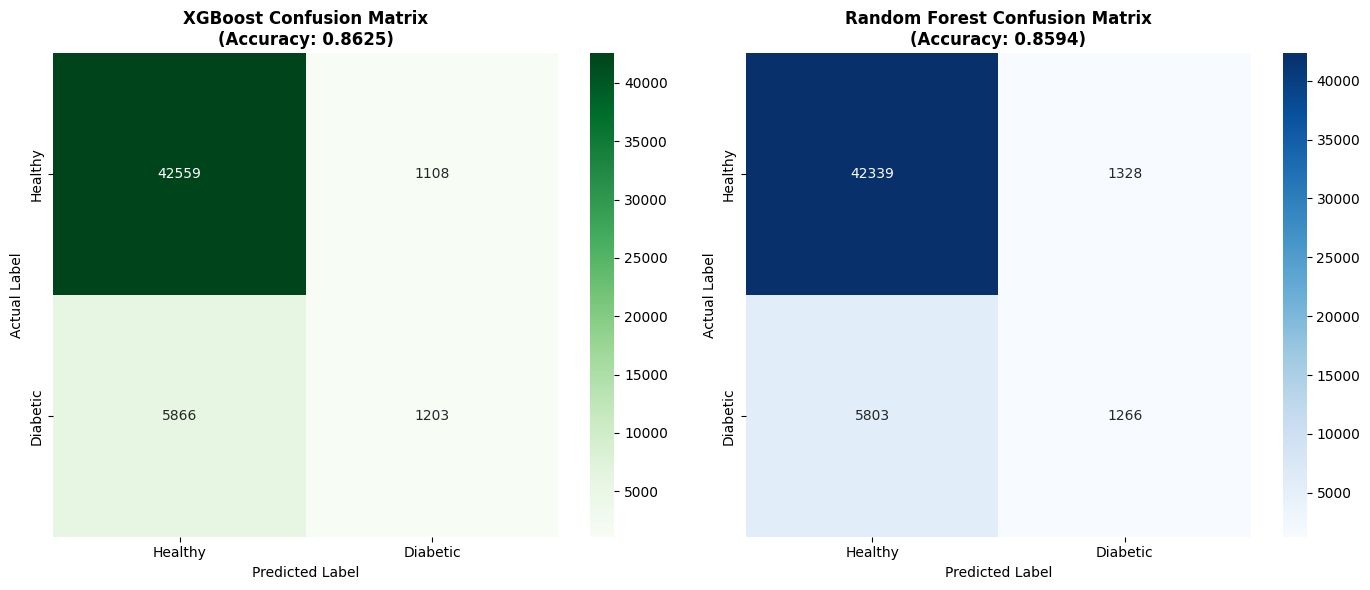

In [10]:
# Plot Confusion Matrices side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
class_names = ['Healthy', 'Diabetic']

# XGBoost Matrix
xgb_cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names, yticklabels=class_names)
ax[0].set_title(f'XGBoost Confusion Matrix\n(Accuracy: {xgb_acc:.4f})', fontweight='bold')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# Random Forest Matrix
rf_cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names, yticklabels=class_names)
ax[1].set_title(f'Random Forest Confusion Matrix\n(Accuracy: {rf_acc:.4f})', fontweight='bold')
ax[1].set_ylabel('Actual Label')
ax[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()